In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
def run_prescribed():

    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False, render_mode='human')

    state = env.reset()[0] # reset to initial position
    terminated = False     # True when fall in hole or reach goal
    truncated  = False     # True when actions > 200

    actionList = [1,2,1,1,1,1,1,1,1,1,1,1]

    pos = 0

    while (not terminated and not truncated):

        action = actionList[pos]

        new_state, reward, terminated, truncated, _ = env.step(action)

        state = new_state
        print(state)
        pos = pos+1


    #env.close()

run_prescribed()

8
9
17
25
33
41


In [3]:
# Random walk

def run_random():

    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False, render_mode='human')

    state = env.reset()[0] # reset to initial position
    terminated = False     # True when fall in hole or reach goal
    truncated  = False     # True when actions > 200

    while (not terminated and not truncated):

        action = env.action_space.sample()

        new_state, reward, terminated, truncated, _ = env.step(action)

        state = new_state
        print(state)


In [4]:
if __name__ == '__main__':
    run_random()

0
1
9
10
18
26
27
28
27
35


In [ ]:
def run(episodes, is_training=True, render=False):

    env = gym.make('FrozenLake-v1', map_name="8x8", is_slippery=False, render_mode='human' if render else None)

    if(is_training):
        q = np.zeros((env.observation_space.n, env.action_space.n)) # a 64 x 4 array
    else:
        f = open("frozen_lake8x8.pkl",'rb')
        q = pickle.load(f)
        f.close()

    learning_rate_a = 0.9
    discount_factor_g = 0.9

    epsilon = 1  
    epsilon_decay_rate = 0.0001
    rng = np.random.default_rng()   # random number gen

    rewards_per_episode = np.zeros(episodes)


    for i in range(episodes):

        state = env.reset()[0] # reset to initial position
        terminated = False     # True when fall in hole or reach goal
        truncated  = False     # True when actions > 200


        while (not terminated and not truncated):
            if is_training and rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q[state,:])

            new_state, reward, terminated, truncated, _ = env.step(action)

            if is_training:
                q[state,action] = q[state,action] + learning_rate_a*(reward + discount_factor_g*np.max(q[new_state,:])-q[state,action])

            state = new_state
    
        epsilon = max(epsilon - epsilon_decay_rate,0)

        if epsilon==0:
            learning_rate_a = 0.0001

        if reward == 1:
            print("Success")
            rewards_per_episode[i] = 1

    #env.close()

    sum_rewards = np.zeros(episodes)
    for t in range(episodes):
        sum_rewards[t] = np.sum(rewards_per_episode[max(0,t-100):(t+1)])
    plt.plot(sum_rewards)
    plt.show()

    if is_training:
        f = open("frozen_lake8x8.pkl","wb")
        pickle.dump(q,f)
        f.close()


Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success
Success


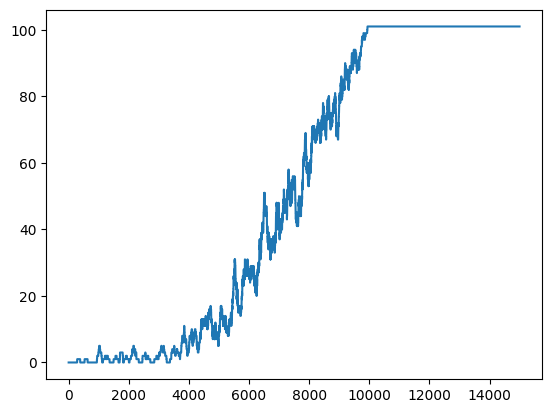

In [8]:
run(15000, is_training= True)

Success


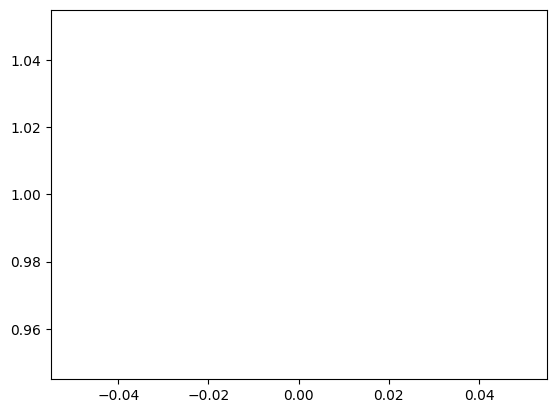

In [12]:
run(1,is_training = False,render=True)